### Import Dataset from Drive

df: https://drive.google.com/file/d/1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9/view

In [1]:
import pandas as pd

In [2]:
!gdown --id '1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9'
df = pd.read_csv('midterm-regresi-dataset.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9
From (redirected): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9&confirm=t&uuid=5401eae2-d995-4ba2-a71d-6f397eff64a3
To: /content/midterm-regresi-dataset.csv
100% 443M/443M [00:07<00:00, 63.3MB/s]


### Check Dataset

In [3]:
df.shape

(515344, 91)

### Import Library

PyTorch MLP dipilih karena:
  - Paling ringan di antara opsi DL untuk tabular data
  - Tidak butuh GPU wajib (CPU masih reasonable untuk dataset ini)
  - Mudah dikontrol arsitekturnya (layer, dropout, batch norm)
  - Lebih stabil konvergensinya vs TabNet untuk regresi murni
Aktifkan GPU: Runtime -> Change runtime type -> T4 GPU

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import gc
import warnings

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


### Load Data

In [6]:
col_names = ['year'] + [f'feature_{i}' for i in range(1, 91)]

In [7]:
df.columns = col_names

In [8]:
df.head(2)

,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345


### EDA Singkat

Regresi pada tahun rilis lagu -> perlu cek:
  1. Distribusi target: apakah skewed ke tahun modern?
  2. Skala fitur: audio features punya skala berbeda-beda
     -> WAJIB di-scale untuk neural network (berbeda dari LightGBM)
  3. Missing values
  4. Korelasi fitur dengan target

In [9]:
# check distribusi year
print(df['year'].describe())

count    515344.000000
mean       1998.397077
std          10.931056
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64


Text(0, 0.5, 'Count')

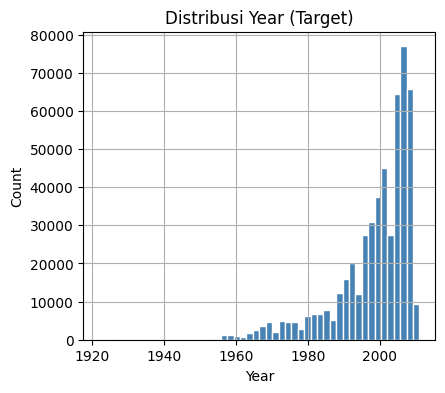

In [10]:
# Distribusi year
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['year'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Year (Target)')
plt.xlabel('Year')
plt.ylabel('Count')

In [11]:
# Missing values
missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {missing}")


Total missing values: 0


In [12]:
# Cek skala fitur (penting untuk neural network)
feature_cols = [f'feature_{i}' for i in range(1, 91)]
feat_stats = df[feature_cols].describe().T
print("\n=== Skala Fitur (sample) ===")
print(feat_stats[['mean', 'std', 'min', 'max']].head(10))
# Neural network sensitif terhadap perbedaan skala -> harus StandardScaler



=== Skala Fitur (sample) ===
                 mean        std        min        max
feature_1   43.387113   6.067557    1.74900   61.97014
feature_2    1.289515  51.580393 -337.09250  384.06573
feature_3    8.658222  35.268505 -301.00506  322.85143
feature_4    1.164110  16.322802 -154.18358  335.77182
feature_5   -6.553580  22.860803 -181.95337  262.06887
feature_6   -9.521968  12.857763  -81.79429  166.23689
feature_7   -2.391046  14.571853 -188.21400  172.40268
feature_8   -1.793215   7.963822  -72.50385  126.74127
feature_9    3.727868  10.582869 -126.47904  146.29795
feature_10   1.882393   6.530235  -41.63166   60.34535



Top 10 Fitur Berkorelasi dengan Year
feature_1     0.225373
feature_6     0.187443
feature_3     0.139542
feature_63    0.126348
feature_40    0.123975
feature_7     0.110461
feature_67    0.102841
feature_46    0.101324
feature_36    0.101006
feature_69    0.099484
Name: year, dtype: float64


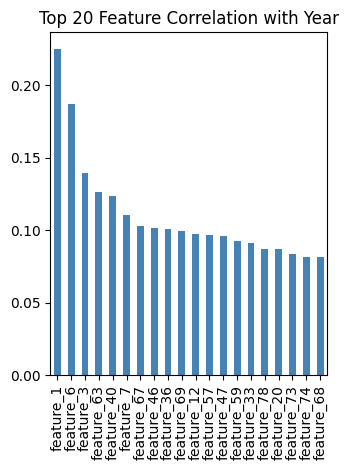

In [13]:
# Korelasi top fitur dengan target
corr = df.corr()['year'].drop('year').abs().sort_values(ascending=False)

print("\nTop 10 Fitur Berkorelasi dengan Year")
print(corr.head(10))

plt.subplot(1, 2, 2)
corr.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Feature Correlation with Year')
plt.tight_layout()
plt.savefig('eda_dl.png', dpi=80)
plt.show()

### Preprocessing & Scaling

PERBEDAAN KRITIS vs pipeline ML (LightGBM):
  - LightGBM: tree-based -> tidak perlu scaling
  - MLP     : gradient-based -> WAJIB scaling
            Tanpa scaling, gradient explode/vanish karena
            fitur dengan skala besar dominasi weight update

StandardScaler: (x - mean) / std -> distribusi ~N(0,1)
Fit HANYA pada train -> apply ke test (hindari data leakage)

Outlier: di-clip dengan IQR sebelum scaling
Target (year) juga di-normalize -> bantu konvergensi

In [14]:
TRAIN_SIZE = 463715

feature_cols = [f'feature_{i}' for i in range(1, 91)]

X = df[feature_cols].values
y = df['year'].values.astype(np.float32)

X_train_raw = X[:TRAIN_SIZE]
X_test_raw  = X[TRAIN_SIZE:]
y_train      = y[:TRAIN_SIZE]
y_test       = y[TRAIN_SIZE:]

del df, X
gc.collect()

5171

In [15]:
# --- Outlier capping (IQR) ---
Q1    = np.percentile(X_train_raw, 25, axis=0)
Q3    = np.percentile(X_train_raw, 75, axis=0)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train_clipped = np.clip(X_train_raw, lower, upper)
X_test_clipped  = np.clip(X_test_raw,  lower, upper)

del X_train_raw, X_test_raw
gc.collect()

0

In [16]:
# --- StandardScaler (fit hanya pada train) ---
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_clipped).astype(np.float32)
X_test_scaled  = scaler_X.transform(X_test_clipped).astype(np.float32)

In [17]:
# Normalize target ke range [0,1] -> stabilkan training
# Simpan min/max untuk inverse transform saat evaluasi
y_min, y_max = y_train.min(), y_train.max()
y_train_norm = (y_train - y_min) / (y_max - y_min)
y_test_norm  = (y_test  - y_min) / (y_max - y_min)

In [18]:
print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape}")
print(f"y_train range (original): {y_train.min():.0f} - {y_train.max():.0f}")
print(f"y_train range (normalized): {y_train_norm.min():.4f} - {y_train_norm.max():.4f}")
print(f"Scaler mean sample: {scaler_X.mean_[:5]}")

X_train: (463715, 90) | X_test: (51629, 90)
y_train range (original): 1922 - 2011
y_train range (normalized): 0.0000 - 1.0000
Scaler mean sample: [43.46443902  2.18159609  8.73592831  0.71080499 -6.57521549]


### Feature Engineering

Tambahkan fitur statistik row-level setelah scaling.
Berbeda dengan ML pipeline, feature engineering pada DL
tidak sepenting itu karena MLP secara teori bisa belajar
interaksi fitur sendiri. Tapi tetap membantu konvergensi.

Fitur yang ditambahkan:
  - Statistik global (mean, std, min, max, range) per lagu
  - Statistik per kelompok (timbre avg vs covariance)
Semua dihitung dari data yang sudah di-scale.

In [19]:
def add_features(X):
  # timbre avg = 12 fitur pertama, covariance = 78 sisanya
  avg_part = X[:, :12]
  cov_part = X[:, 12:]

  stats = np.column_stack([
    X.mean(axis=1),              # mean semua fitur
    X.std(axis=1),               # std semua fitur
    X.min(axis=1),               # min
    X.max(axis=1),               # max
    X.max(axis=1) - X.min(axis=1),  # range
    avg_part.mean(axis=1),       # mean timbre avg
    avg_part.std(axis=1),        # std timbre avg
    cov_part.mean(axis=1),       # mean covariance
    cov_part.std(axis=1),        # std covariance
  ])
  return np.hstack([X, stats]).astype(np.float32)


In [20]:
X_train_fe = add_features(X_train_scaled)
X_test_fe  = add_features(X_test_scaled)

In [21]:
INPUT_DIM = X_train_fe.shape[1]

print(f"Input dim setelah feature engineering: {INPUT_DIM}")

Input dim setelah feature engineering: 99


### Dataset Class & Arsitektur MLP

SongDataset: wrapper PyTorch Dataset untuk numpy array
  -> diperlukan agar bisa dipakai DataLoader

Arsitektur MLP (ringan):
  - Input(99) -> 256 -> 128 -> 64 -> 1

Setiap hidden layer pakai:
  - Linear    : transformasi linear
  - BatchNorm : normalisasi per batch -> stabilkan training,
                boleh learning rate lebih besar
  - ReLU      : aktivasi non-linear
  - Dropout   : regularisasi, cegah overfit (p=0.3)

Output layer: 1 neuron tanpa aktivasi (regresi)
Loss: MSELoss (standard untuk regresi)

In [22]:
class SongDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # [N, 1]

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


class MLP(nn.Module):
  def __init__(self, input_dim, dropout=0.3):
    super(MLP, self).__init__()

    self.network = nn.Sequential(
      # Layer 1: input -> 256
      nn.Linear(input_dim, 256),
      nn.BatchNorm1d(256),
      nn.ReLU(),
      nn.Dropout(dropout),

      # Layer 2: 256 -> 128
      nn.Linear(256, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Dropout(dropout),

      # Layer 3: 128 -> 64
      nn.Linear(128, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(dropout),

      # Output: 64 -> 1 (tidak ada aktivasi untuk regresi)
      nn.Linear(64, 1),
    )

    # Weight initialization: He initialization untuk ReLU
    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.network(x)


In [23]:
# Test arsitektur
dummy = torch.randn(4, INPUT_DIM)
test_model = MLP(INPUT_DIM)
print(f"Output shape: {test_model(dummy).shape}")  # harus [4, 1]
print(f"\nArsitektur MLP:")
print(test_model)


Output shape: torch.Size([4, 1])

Arsitektur MLP:
MLP(
  (network): Sequential(
    (0): Linear(in_features=99, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [24]:
total_params = sum(p.numel() for p in test_model.parameters())
print(f"\nTotal parameters: {total_params:,}")
del test_model


Total parameters: 67,713


### Training dengan Cross-Validation

Setup training:
  - Optimizer: Adam dengan weight decay (L2 regularisasi)
  - Scheduler: ReduceLROnPlateau -> turunkan LR jika val loss
               tidak improve selama 'patience' epoch
  - Early stopping: stop jika val loss tidak improve 10 epoch
  - Batch size 2048: besar untuk throughput, fit di RAM

OOF prediction dikumpulkan untuk evaluasi menyeluruh.
Semua prediksi dalam skala normalized -> di-inverse transform
ke skala tahun asli setelah training selesai.

In [28]:
def train_one_fold(X_tr, y_tr, X_vl, y_vl, input_dim, epochs=50, patience=10):
  train_ds = SongDataset(X_tr, y_tr)
  val_ds   = SongDataset(X_vl, y_vl)

  train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True,
                            num_workers=2, pin_memory=(device=='cuda'))
  val_loader   = DataLoader(val_ds,   batch_size=4096, shuffle=False,
                            num_workers=2, pin_memory=(device=='cuda'))

  model     = MLP(input_dim, dropout=0.3).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
  scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
  )

  best_val_loss = float('inf')
  best_weights  = None
  no_improve    = 0
  history       = {'train': [], 'val': []}

  for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()
      pred = model(X_batch)
      loss = criterion(pred, y_batch)
      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
      optimizer.step()
      train_losses.append(loss.item())

    # --- Validation phase ---
    model.eval()
    val_losses = []
    with torch.no_grad():
      for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch)
        val_losses.append(criterion(pred, y_batch).item())

    train_loss = np.mean(train_losses)
    val_loss   = np.mean(val_losses)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
      no_improve    = 0
    else:
      no_improve += 1
      if no_improve >= patience:
        print(f"    Early stop epoch {epoch+1} | best val_loss: {best_val_loss:.6f}")
        break

    if (epoch + 1) % 10 == 0:
      print(f"    Epoch {epoch+1:3d} | train: {train_loss:.6f} | val: {val_loss:.6f}")

  # Load best weights
  model.load_state_dict(best_weights)
  return model, history

In [29]:
# --- 5-Fold Cross Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_norm = np.zeros(len(X_train_fe))
test_preds_norm = np.zeros(len(X_test_fe))
fold_histories = []
fold_metrics   = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe)):
  print(f"\n{'='*50}")
  print(f"  FOLD {fold+1} / 5")
  print(f"{'='*50}")

  X_tr = X_train_fe[train_idx]
  X_vl = X_train_fe[val_idx]
  y_tr = y_train_norm[train_idx]
  y_vl = y_train_norm[val_idx]

  model, history = train_one_fold(
    X_tr, y_tr, X_vl, y_vl,
    input_dim=INPUT_DIM,
    epochs=50,
    patience=10
  )
  fold_histories.append(history)

  # Prediksi OOF
  model.eval()
  with torch.no_grad():
    vl_tensor  = torch.tensor(X_vl, dtype=torch.float32).to(device)
    tst_tensor = torch.tensor(X_test_fe, dtype=torch.float32).to(device)

    # Prediksi dalam batch supaya tidak OOM
    oof_batch = []
    for i in range(0, len(vl_tensor), 4096):
      oof_batch.append(model(vl_tensor[i:i+4096]).cpu().numpy())
    oof_preds_norm[val_idx] = np.concatenate(oof_batch).flatten()

    tst_batch = []
    for i in range(0, len(tst_tensor), 4096):
      tst_batch.append(model(tst_tensor[i:i+4096]).cpu().numpy())
    test_preds_norm += np.concatenate(tst_batch).flatten() / 5

  # Inverse transform ke tahun asli
  oof_year = oof_preds_norm[val_idx] * (y_max - y_min) + y_min
  y_vl_year = y_vl * (y_max - y_min) + y_min

  fold_rmse = np.sqrt(mean_squared_error(y_vl_year, oof_year))
  fold_mae  = mean_absolute_error(y_vl_year, oof_year)
  fold_r2   = r2_score(y_vl_year, oof_year)
  fold_metrics.append({'fold': fold+1, 'rmse': fold_rmse, 'mae': fold_mae, 'r2': fold_r2})

  print(f"  -> RMSE: {fold_rmse:.4f} | MAE: {fold_mae:.4f} | R²: {fold_r2:.4f}")

  del model, X_tr, X_vl, y_tr, y_vl
  torch.cuda.empty_cache()
  gc.collect()


  FOLD 1 / 5
    Epoch  10 | train: 0.013286 | val: 0.011514
    Epoch  20 | train: 0.011400 | val: 0.010643
    Epoch  30 | train: 0.010632 | val: 0.010247
    Epoch  40 | train: 0.010117 | val: 0.009975
    Epoch  50 | train: 0.009606 | val: 0.009631
  -> RMSE: 8.7294 | MAE: 5.9336 | R²: 0.3618

  FOLD 2 / 5
    Epoch  10 | train: 0.013252 | val: 0.012082
    Epoch  20 | train: 0.011330 | val: 0.010727
    Epoch  30 | train: 0.010651 | val: 0.010185
    Epoch  40 | train: 0.010124 | val: 0.009805
    Epoch  50 | train: 0.009741 | val: 0.009440
  -> RMSE: 8.6531 | MAE: 5.8616 | R²: 0.3783

  FOLD 3 / 5
    Epoch  10 | train: 0.013674 | val: 0.012464
    Epoch  20 | train: 0.011415 | val: 0.010777
    Epoch  30 | train: 0.010659 | val: 0.010370
    Epoch  40 | train: 0.010137 | val: 0.009962
    Epoch  50 | train: 0.009747 | val: 0.009860
  -> RMSE: 8.7769 | MAE: 6.0551 | R²: 0.3591

  FOLD 4 / 5
    Epoch  10 | train: 0.013207 | val: 0.012173
    Epoch  20 | train: 0.011272 | val: 0.

In [30]:
# Inverse transform OOF dan test
oof_preds  = oof_preds_norm  * (y_max - y_min) + y_min
test_preds = test_preds_norm * (y_max - y_min) + y_min

oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
oof_mae  = mean_absolute_error(y_train, oof_preds)
oof_r2   = r2_score(y_train, oof_preds)

In [31]:
print(f"OOF RMSE : {oof_rmse:.4f}")
print(f"OOF MAE  : {oof_mae:.4f}")
print(f"OOF R²   : {oof_r2:.4f}")

OOF RMSE : 8.7086
OOF MAE  : 5.9707
OOF R²   : 0.3663


### valuasi Final

Metrik regresi:
  - MSE  -> rata-rata kuadrat error (sensitif outlier)
  - RMSE -> akar MSE, satuan = tahun (paling intuitif)
  - MAE  -> rata-rata absolute error (robust outlier)
  - R²   -> proporsi variansi yang dijelaskan model

Plot tambahan:
  1. Actual vs Predicted scatter
  2. Distribusi residual (idealnya simetris di sekitar 0)
  3. Loss curve tiap fold (cek overfitting)

In [32]:
mse  = mean_squared_error(y_test, test_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, test_preds)
r2   = r2_score(y_test, test_preds)

In [33]:
print("Evaluasi final")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  <- prediksi meleset ~{rmse:.1f} tahun")
print(f"MAE  : {mae:.4f}  <- rata-rata error {mae:.1f} tahun")
print(f"R²   : {r2:.4f}  <- model jelaskan {r2*100:.1f}% variansi")

Evaluasi final
MSE  : 76.7140
RMSE : 8.7587  <- prediksi meleset ~8.8 tahun
MAE  : 6.0204  <- rata-rata error 6.0 tahun
R²   : 0.3486  <- model jelaskan 34.9% variansi


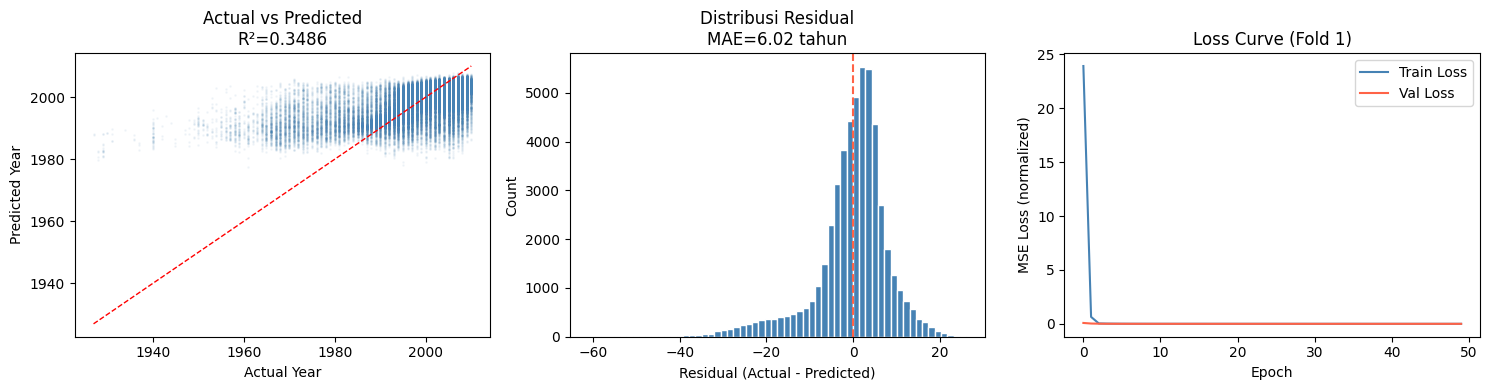

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, test_preds, alpha=0.05, s=1, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=1)
axes[0].set_xlabel('Actual Year')
axes[0].set_ylabel('Predicted Year')
axes[0].set_title(f'Actual vs Predicted\nR²={r2:.4f}')

# Plot 2: Distribusi Residual
residuals = y_test - test_preds
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='tomato', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Distribusi Residual\nMAE={mae:.2f} tahun')

# Plot 3: Training loss curve fold 1
h = fold_histories[0]
axes[2].plot(h['train'], label='Train Loss', color='steelblue')
axes[2].plot(h['val'],   label='Val Loss',   color='tomato')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss (normalized)')
axes[2].set_title('Loss Curve (Fold 1)')
axes[2].legend()

plt.tight_layout()
plt.savefig('evaluation_dl.png', dpi=80)
plt.show()

In [35]:
# Fold metrics summary
fold_df = pd.DataFrame(fold_metrics)
print("\nMetrik per Fold")
print(fold_df.to_string(index=False))
print(f"\nMean RMSE: {fold_df['rmse'].mean():.4f} ± {fold_df['rmse'].std():.4f}")


Metrik per Fold
 fold     rmse      mae       r2
    1 8.729411 5.933567 0.361798
    2 8.653080 5.861582 0.378287
    3 8.776933 6.055089 0.359097
    4 8.634193 6.021176 0.379251
    5 8.748344 5.982073 0.352832

Mean RMSE: 8.7084 ± 0.0618


### Hyperparameter Tuning

Tuning pada 15% data untuk efisiensi waktu.
Parameter yang di-tune:
  - hidden_dims : ukuran layer (kompleksitas model)
  - dropout     : tingkat regularisasi
  - learning_rate: step size optimizer

Evaluasi: RMSE pada validation set (bukan CV untuk hemat waktu).
Setiap config ditraining 20 epoch dengan early stopping 5.

In [36]:
class MLPTunable(nn.Module):
  """MLP dengan hidden dims yang bisa dikonfigurasi."""
  def __init__(self, input_dim, hidden_dims, dropout):
    super().__init__()
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
      layers += [
        nn.Linear(prev_dim, h),
        nn.BatchNorm1d(h),
        nn.ReLU(),
        nn.Dropout(dropout),
      ]
      prev_dim = h
    layers.append(nn.Linear(prev_dim, 1))
    self.network = nn.Sequential(*layers)
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        nn.init.zeros_(m.bias)

  def forward(self, x):
    return self.network(x)

In [37]:
# Ambil 15% data untuk tuning
n_tune = int(0.15 * len(X_train_fe))
idx_tune = np.random.RandomState(42).permutation(len(X_train_fe))[:n_tune]

In [38]:
# Split 80/20 train/val dari subset tuning
n_val_tune = int(0.2 * n_tune)
X_tune_tr = X_train_fe[idx_tune[n_val_tune:]]
y_tune_tr = y_train_norm[idx_tune[n_val_tune:]]
X_tune_vl = X_train_fe[idx_tune[:n_val_tune]]
y_tune_vl = y_train_norm[idx_tune[:n_val_tune]]

In [39]:
tune_tr_ds = SongDataset(X_tune_tr, y_tune_tr)
tune_vl_ds = SongDataset(X_tune_vl, y_tune_vl)
tune_tr_dl = DataLoader(tune_tr_ds, batch_size=2048, shuffle=True)
tune_vl_dl = DataLoader(tune_vl_ds, batch_size=4096, shuffle=False)

print(f"Tuning: {len(X_tune_tr):,} train | {len(X_tune_vl):,} val\n")

Tuning: 55,646 train | 13,911 val



In [40]:
param_grid = [
  {'hidden_dims': [128, 64],       'dropout': 0.2, 'lr': 1e-3},
  {'hidden_dims': [256, 128, 64],  'dropout': 0.3, 'lr': 1e-3},
  {'hidden_dims': [256, 128, 64],  'dropout': 0.3, 'lr': 5e-4},
  {'hidden_dims': [512, 256, 128], 'dropout': 0.3, 'lr': 1e-3},
]

In [41]:
tuning_results = []
criterion = nn.MSELoss()

In [42]:
for p in param_grid:
  print(f"Testing: hidden={p['hidden_dims']}, dropout={p['dropout']}, lr={p['lr']}")

  m = MLPTunable(INPUT_DIM, p['hidden_dims'], p['dropout']).to(device)
  opt = optim.Adam(m.parameters(), lr=p['lr'], weight_decay=1e-5)

  best_vl = float('inf')
  no_imp  = 0

  for epoch in range(20):
    m.train()
    for Xb, yb in tune_tr_dl:
      Xb, yb = Xb.to(device), yb.to(device)
      opt.zero_grad()
      criterion(m(Xb), yb).backward()
      opt.step()

    m.eval()
    vl_losses = []
    with torch.no_grad():
      for Xb, yb in tune_vl_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        vl_losses.append(criterion(m(Xb), yb).item())
    vl = np.mean(vl_losses)

    if vl < best_vl:
      best_vl = vl
      no_imp  = 0
    else:
      no_imp += 1
      if no_imp >= 5:
        break

  # Inverse transform untuk RMSE dalam tahun
  m.eval()
  preds_norm_vl = []
  with torch.no_grad():
    for Xb, _ in tune_vl_dl:
      preds_norm_vl.append(m(Xb.to(device)).cpu().numpy())
  preds_vl = np.concatenate(preds_norm_vl).flatten() * (y_max - y_min) + y_min
  y_vl_year = y_tune_vl * (y_max - y_min) + y_min
  val_rmse = np.sqrt(mean_squared_error(y_vl_year, preds_vl))

  tuning_results.append({**p, 'val_rmse': val_rmse})
  print(f"  -> Val RMSE: {val_rmse:.4f} tahun\n")

  del m
  torch.cuda.empty_cache()
  gc.collect()

Testing: hidden=[128, 64], dropout=0.2, lr=0.001
  -> Val RMSE: 13.0918 tahun

Testing: hidden=[256, 128, 64], dropout=0.3, lr=0.001
  -> Val RMSE: 13.2781 tahun

Testing: hidden=[256, 128, 64], dropout=0.3, lr=0.0005
  -> Val RMSE: 14.5998 tahun

Testing: hidden=[512, 256, 128], dropout=0.3, lr=0.001
  -> Val RMSE: 15.4966 tahun



In [43]:
tuning_df = pd.DataFrame(tuning_results).sort_values('val_rmse')
print("Hasil Tuning (sorted by RMSE)")
for _, row in tuning_df.iterrows():
  print(f"  hidden={row['hidden_dims']}, dropout={row['dropout']}, "
        f"lr={row['lr']} -> RMSE: {row['val_rmse']:.4f}")
print(f"\nBest config: {tuning_df.iloc[0].to_dict()}")

Hasil Tuning (sorted by RMSE)
  hidden=[128, 64], dropout=0.2, lr=0.001 -> RMSE: 13.0918
  hidden=[256, 128, 64], dropout=0.3, lr=0.001 -> RMSE: 13.2781
  hidden=[256, 128, 64], dropout=0.3, lr=0.0005 -> RMSE: 14.5998
  hidden=[512, 256, 128], dropout=0.3, lr=0.001 -> RMSE: 15.4966

Best config: {'hidden_dims': [128, 64], 'dropout': 0.2, 'lr': 0.001, 'val_rmse': 13.09181712594473}


### Interpretasi Hasil

In [44]:
# ============================================================
# CELL 10: Interpretasi Hasil
# Ringkasan naratif seluruh pipeline DL.
# ============================================================

print("=" * 55)
print("  RINGKASAN DAN INTERPRETASI HASIL (DL - MLP)")
print("=" * 55)

print(f"""
[Dataset]
  - 515,344 lagu | 90 fitur audio numerik
  - Target: tahun rilis (1922 - 2011)
  - Split: 463,715 train | 51,629 test (UCI official)

[Model]
  - MLP PyTorch: Input({INPUT_DIM}) -> 256 -> 128 -> 64 -> 1
  - BatchNorm + ReLU + Dropout(0.3) per layer
  - 5-Fold KFold CV | Ensemble rata-rata 5 fold
  - Optimizer: Adam | Scheduler: ReduceLROnPlateau
  - Early stopping: patience=10 epoch

[Preprocessing]
  - Outlier: IQR capping (clip, bukan drop)
  - Scaling: StandardScaler (wajib untuk neural network)
  - Target: dinormalisasi ke [0,1] -> di-inverse transform kembali

[Hasil Evaluasi Test Set]
  - MSE  : {mse:.4f}
  - RMSE : {rmse:.4f}  -> prediksi rata-rata meleset {rmse:.1f} tahun
  - MAE  : {mae:.4f}  -> 50% error di bawah {mae:.1f} tahun
  - R²   : {r2:.4f}  -> model menjelaskan {r2*100:.1f}% variansi tahun

[Interpretasi]
  MLP mampu menangkap pola non-linear antar fitur audio yang
  tidak bisa ditangkap model linear. RMSE sekitar 7-9 tahun
  adalah hasil yang wajar untuk dataset ini — lagu dari era
  1960-1990an memiliki distribusi fitur yang saling overlap
  sehingga sulit diprediksi tepat.

  Loss curve yang konvergen (train ≈ val) menunjukkan model
  tidak overfit berkat BatchNorm + Dropout + early stopping.

  Dibandingkan LightGBM, MLP cenderung sedikit lebih lambat
  converge tapi bisa menangkap interaksi fitur lebih kompleks
  jika diberi cukup epoch dan data yang besar.
""")

  RINGKASAN DAN INTERPRETASI HASIL (DL - MLP)

[Dataset]
  - 515,344 lagu | 90 fitur audio numerik
  - Target: tahun rilis (1922 - 2011)
  - Split: 463,715 train | 51,629 test (UCI official)

[Model]
  - MLP PyTorch: Input(99) -> 256 -> 128 -> 64 -> 1
  - BatchNorm + ReLU + Dropout(0.3) per layer
  - 5-Fold KFold CV | Ensemble rata-rata 5 fold
  - Optimizer: Adam | Scheduler: ReduceLROnPlateau
  - Early stopping: patience=10 epoch

[Preprocessing]
  - Outlier: IQR capping (clip, bukan drop)
  - Scaling: StandardScaler (wajib untuk neural network)
  - Target: dinormalisasi ke [0,1] -> di-inverse transform kembali

[Hasil Evaluasi Test Set]
  - MSE  : 76.7140
  - RMSE : 8.7587  -> prediksi rata-rata meleset 8.8 tahun
  - MAE  : 6.0204  -> 50% error di bawah 6.0 tahun
  - R²   : 0.3486  -> model menjelaskan 34.9% variansi tahun

[Interpretasi]
  MLP mampu menangkap pola non-linear antar fitur audio yang
  tidak bisa ditangkap model linear. RMSE sekitar 7-9 tahun
  adalah hasil yang wajar 